In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("Electric_Production.csv")

df.head()

,DATE,IPG2211A2N
0,1/1/1985,72.5052
1,2/1/1985,70.6720
2,3/1/1985,62.4502
3,4/1/1985,57.4714
4,5/1/1985,55.3151


In [3]:
# Convert DATE column to datetime
df['DATE'] = pd.to_datetime(df['DATE'])

# Sort by date
df = df.sort_values('DATE')

# Set DATE as index
df.set_index('DATE', inplace=True)

df.head()

,IPG2211A2N
DATE,
1985-01-01,72.5052
1985-02-01,70.6720
1985-03-01,62.4502
1985-04-01,57.4714
1985-05-01,55.3151


In [4]:
df.isnull().sum()

df = df.dropna()

In [5]:
df['lag_1'] = df.iloc[:, 0].shift(1)
df['lag_2'] = df.iloc[:, 0].shift(2)
df['lag_3'] = df.iloc[:, 0].shift(3)

df = df.dropna()

In [6]:
X = df[['lag_1', 'lag_2', 'lag_3']]
y = df.iloc[:, 0]  # main production column

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [8]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [9]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [10]:
def evaluate_model(name, y_true, y_pred):
    print(f"{name}")
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2 Score:", r2_score(y_true, y_pred))
    print("-" * 30)

evaluate_model("Decision Tree", y_test, dt_pred)
evaluate_model("Random Forest", y_test, rf_pred)

Decision Tree
RMSE: 8.870576830900651
R2 Score: 0.1506359044919443
------------------------------
Random Forest
RMSE: 7.311380624157006
R2 Score: 0.42298253053320856
------------------------------


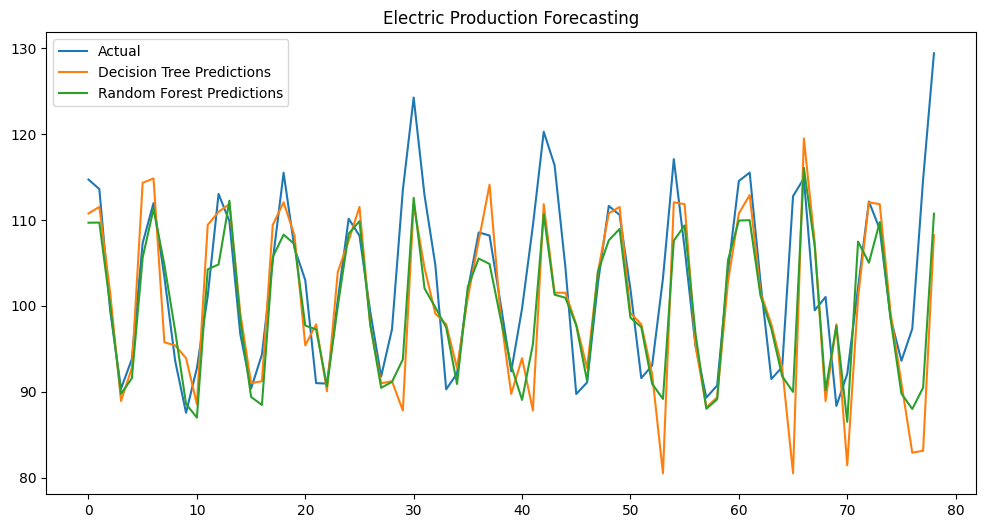

In [11]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual")
plt.plot(dt_pred, label="Decision Tree Predictions")
plt.plot(rf_pred, label="Random Forest Predictions")

plt.legend()
plt.title("Electric Production Forecasting")
plt.show()

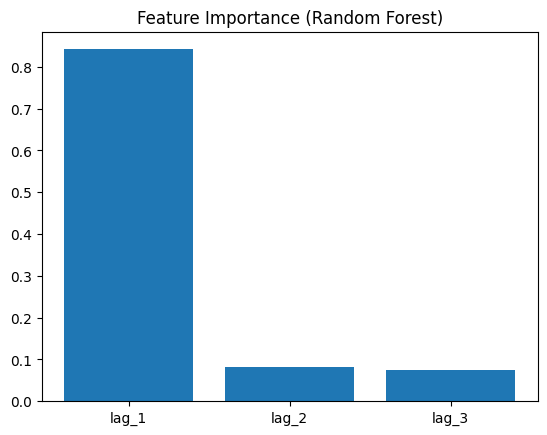

In [12]:
importances = rf_model.feature_importances_
features = X.columns

plt.bar(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.show()